In [ ]:
#импортируем необходимые библиотеки для обработки данных
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer


import scipy

In [ ]:
# Названия таблиц и пояснения к ним

# Таблицы с данными (сначала с пропусками, потом заполненные)
#data_healthy
#data_1_stage
#data_2_stage
#data_3_stage

# Объединённая таблица
#data_glaucoma
#data_glaucoma_after_input
#data_glaucoma_all

# Описательная статистика
#describe_data_healthy
#describe_data_1_stage
#describe_data_2_stage
#describe_data_3_stage

# Агрегированная таблица со средними значениями
#table_agg

# Вспомогательная таблица для заполнения медианой
#median_imputer

# Загрузка подготовленной таблицы

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#загружаем имеющиеся данные
excel_reader=pd.ExcelFile('/content/drive/MyDrive/prepare_data.xlsx')

В таблице с данными 4 листа. Выделим их для удобства работы в отдельные таблицы.

In [ ]:
print(excel_reader.sheet_names)

['healthy', '1_stage', '2_stage', '3_stage']


In [ ]:
data_healthy=excel_reader.parse('healthy')

In [ ]:
data_1_stage=excel_reader.parse('1_stage')

In [ ]:
data_2_stage=excel_reader.parse('2_stage')

In [ ]:
data_3_stage=excel_reader.parse('3_stage')

Имеются 4 таблицы данных без пропусков:

* data_healthy - здоровые пациенты
*   data_1_stage - больные с 1 стадией
* data_2_stage - больные со 2 стадией
* data_3_stage - больные с 3 стадией

In [ ]:
#объединим все таблицы
data_glaucoma_all=pd.concat([data_healthy, data_1_stage, data_2_stage, data_3_stage], axis=0, ignore_index=True)

In [ ]:
del data_glaucoma_all['Фамилия']

In [ ]:
data_glaucoma_all

,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,ЦТР,...,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
0,25,0,10,12,0.0162,9.70,9.40,9.30,11.3,536,...,1.75,0.0162,56.300000,46.030000,49.650,0.27,0.250,979,39.16,1.157570
1,26,0,12,15,0.0162,18.50,19.90,12.80,11.6,537,...,1.85,0.0162,50.960000,44.210000,51.555,0.28,0.275,948,37.92,1.252867
2,32,0,10,12,0.0162,14.30,12.00,8.30,9.2,547,...,1.70,0.0138,53.580000,47.400000,102.330,0.13,0.140,1060,42.40,2.203474
3,32,0,10,12,0.0162,17.60,13.90,7.60,7.6,550,...,1.70,0.0138,56.297266,45.462070,58.430,0.20,0.210,1063,42.52,1.254623
4,68,0,10,14,0.0138,20.10,17.20,8.80,7.9,554,...,1.75,0.0138,48.680000,45.880000,20.970,0.13,0.140,725,29.00,0.660193
5,59,0,12,14,0.0161,8.50,8.10,9.10,11.4,590,...,1.85,0.0161,53.560000,48.420000,35.500,0.52,0.420,917,36.68,0.883629
6,66,0,15,23,0.0076,17.80,15.60,9.10,9.6,507,...,1.30,0.0076,48.710000,45.880000,49.880,0.29,0.300,910,36.40,1.251111
7,66,0,12,16,0.0140,17.80,15.60,9.10,9.6,511,...,1.70,0.0140,52.440000,45.880000,53.230,0.32,0.330,822,32.88,1.478071
8,68,0,18,28,0.0052,20.40,20.00,11.30,9.9,580,...,1.10,0.0052,51.320000,43.700000,51.555,0.28,0.275,948,37.92,1.252867
9,51,0,12,19,0.0031,17.80,16.50,10.00,9.6,525,...,0.60,0.0031,52.440000,45.880000,183.500,0.33,0.400,1210,48.40,3.461477


In [ ]:
# Вначале удаляем столбец
stage = data_glaucoma_all['стадия']
data_glaucoma_all = data_glaucoma_all.drop('стадия', axis=1)

# Затем вставляем его на первое место
data_glaucoma_all.insert(0, 'стадия', stage)

#Определение значимых признаков

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr # Корреляция Пирсона
from scipy.stats import spearmanr # Корреляция Спирмена
from sklearn.feature_selection import mutual_info_classif, f_classif

In [ ]:
# Нормализация признаков
scaler = StandardScaler()
features = data_glaucoma_all.drop(columns=['стадия'])  # Удаляем целевую переменную
features_scaled = scaler.fit_transform(features)

In [ ]:
# Добавляем обратно целевую переменную
data_scaled = pd.DataFrame(features_scaled, columns=features.columns)
data_scaled['стадия'] = data_glaucoma_all['стадия']

In [ ]:
# Корреляция Пирсона
#correlations = []
#for col in features.columns:
#    corr, _ = pearsonr(data_scaled[col], data_scaled['стадия'])
#    correlations.append(abs(corr))

In [ ]:
# Корреляция Спирмена
correlations = []
for col in features.columns:
    corr, _ = spearmanr(data_scaled[col], data_scaled['стадия'])
    correlations.append(abs(corr))

In [ ]:
features_list = [features.columns[i] for i, c in enumerate(correlations) if c > 0]

In [ ]:
features_list

['возраст',
 'величина внутриглазного давления',
 'ВГД, корригированного на коэффициент ригидности',
 'Коэфф ригидности склеральн капсулы глаза',
 'Роговично-компенсированное ВГД',
 'ВГД по Гольдману',
 'Фактор резистентности роговицы',
 'КГ',
 'ЦТР',
 'РП',
 'ГлРП',
 'gamma Ш',
 'Efrid',
 'SVL',
 'DVL',
 'РИ (рео.индекс) мОм',
 'ПМН (макс.нап)',
 'ПМУ (мод.упр.)',
 'Z баз.(отн.))',
 'Z баз.(мОм)',
 'УОК (уд.объем) мкл']

In [ ]:
# Признаки с корреляцией выше порога
corr_threshold = 0.6
significant_corr = [features.columns[i] for i, c in enumerate(correlations) if c > corr_threshold]

In [ ]:
print("Значимые признаки (корреляция):", significant_corr)

Значимые признаки (корреляция): ['Коэфф ригидности склеральн капсулы глаза', 'РП', 'Efrid', 'SVL']


In [ ]:
# Ищем пересечения значимых признаков из всех методов
significant_features_in_all = set(significant_corr)
print ("В пересечении обнаружено", len(significant_features_in_all),"признаков")
print("Значимые признаки:", significant_features_in_all)

В пересечении обнаружено 4 признаков
Значимые признаки: {'SVL', 'Efrid', 'Коэфф ригидности склеральн капсулы глаза', 'РП'}


Визуализируем данные по этим признакам

<ipython-input-85-3636aff70ef8>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='стадия', y=feature, data=data_glaucoma_all, palette='Set2')


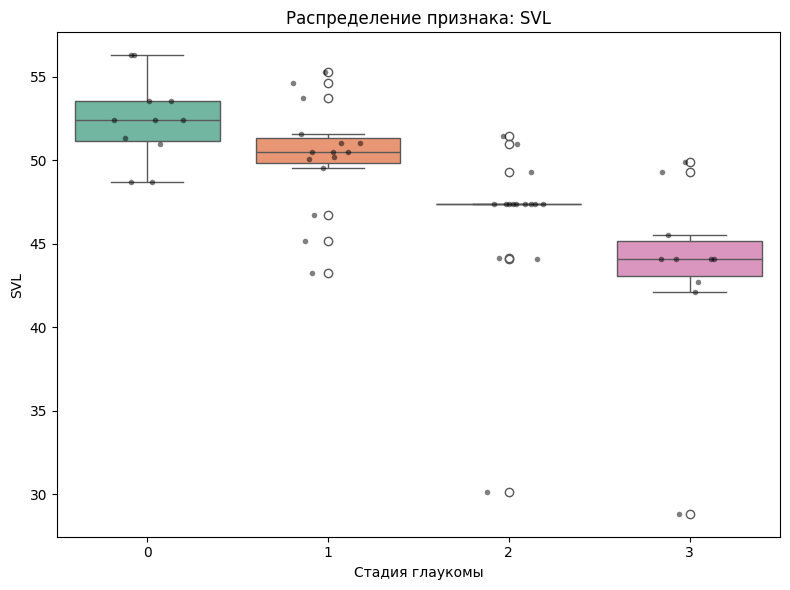

<ipython-input-85-3636aff70ef8>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='стадия', y=feature, data=data_glaucoma_all, palette='Set2')


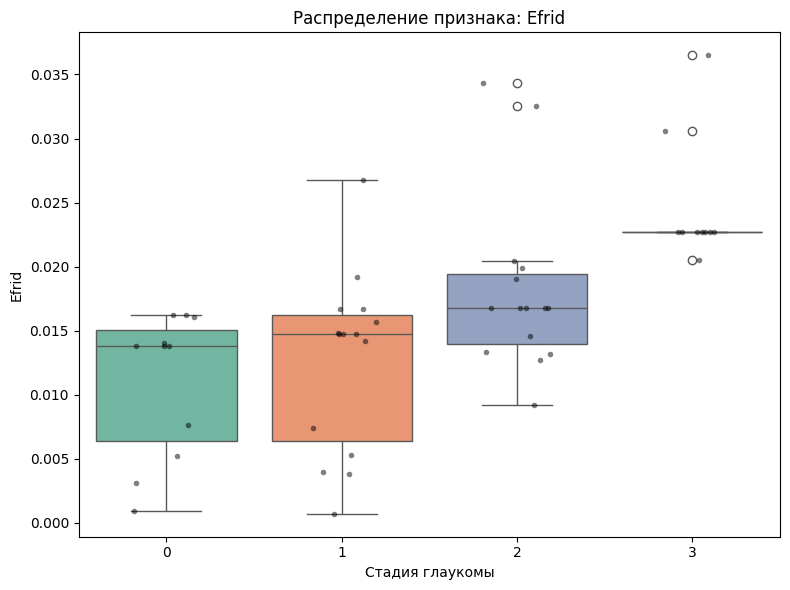

<ipython-input-85-3636aff70ef8>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='стадия', y=feature, data=data_glaucoma_all, palette='Set2')


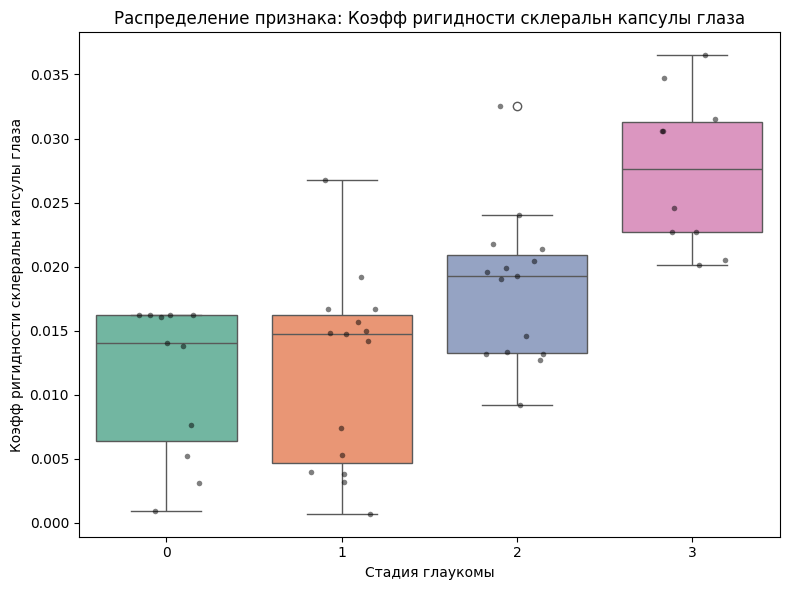

<ipython-input-85-3636aff70ef8>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='стадия', y=feature, data=data_glaucoma_all, palette='Set2')


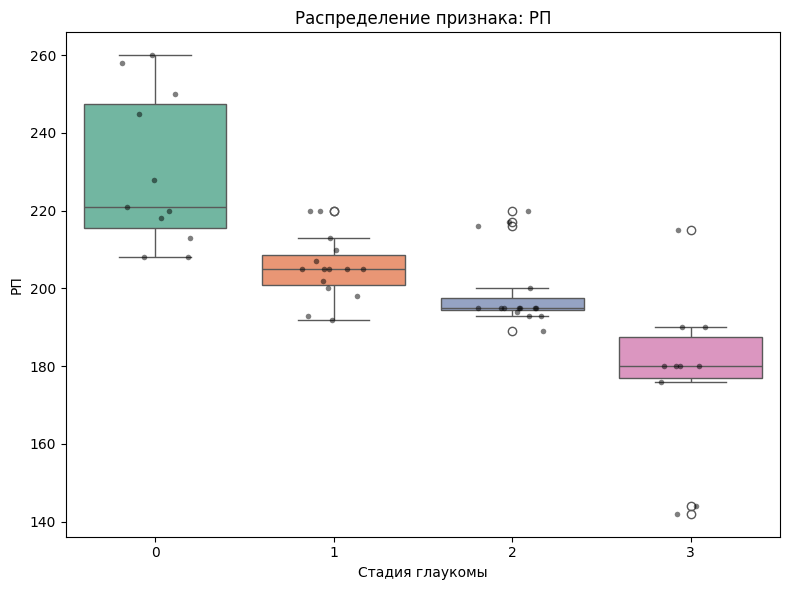

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in significant_features_in_all:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='стадия', y=feature, data=data_glaucoma_all, palette='Set2')
    sns.stripplot(x='стадия', y=feature, data=data_glaucoma_all, color='black', alpha=0.5, jitter=0.2, size=4)
    plt.title(f'Распределение признака: {feature}')
    plt.xlabel('Стадия глаукомы')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

##Альтернативный способ посмотреть значимые признаки

In [ ]:
import pandas as pd
from scipy.stats import f_oneway  # или import kruskal для непараметрической версии

results = []

# Обход всех признаков
for feature in features_list:
    groups = [data_glaucoma_all[data_glaucoma_all['стадия'] == g][feature] for g in sorted(data_glaucoma_all['стадия'].unique())]

    # Расчет p-значения
    stat, pval = f_oneway(*groups)  # или kruskal(*groups)

    # Сохранение результата
    results.append({
        'Признак': feature,
        'F-статистика': round(stat, 4),
        'p-значение': round(pval, 6),
        'Значим (p < 0.01)': pval < 0.01
    })

# Создание датафрейма
results_df = pd.DataFrame(results)

# Сортировка по p-значению
results_df = results_df.sort_values(by='p-значение')

# Вывод
results_df

,Признак,F-статистика,p-значение,Значим (p < 0.01)
0,возраст,15.2115,0.000000,True
9,РП,22.2526,0.000000,True
3,Коэфф ригидности склеральн капсулы глаза,15.1201,0.000001,True
10,ГлРП,13.4273,0.000002,True
14,DVL,12.0994,0.000005,True
12,Efrid,10.5559,0.000020,True
13,SVL,9.7845,0.000040,True
11,gamma Ш,7.5156,0.000330,True
7,КГ,5.7602,0.001934,True
15,РИ (рео.индекс) мОм,3.9439,0.013699,False


Посмотрим как меняются показатели в зависимости от стадии

In [ ]:
import pandas as pd
from scipy.stats import f_oneway  # или kruskal
import numpy as np

results = []

stages = sorted(data_glaucoma_all['стадия'].unique())

for feature in significant_features_in_all:
    groups = [data_glaucoma_all[data_glaucoma_all['стадия'] == g][feature] for g in stages]

    # ANOVA
    stat, pval = f_oneway(*groups)

    # Средние по группам
    means = [group.mean() for group in groups]

    # Описание направления изменения
    if all(earlier < later for earlier, later in zip(means, means[1:])):
        trend = "Увеличивается с прогрессией"
    elif all(earlier > later for earlier, later in zip(means, means[1:])):
        trend = "Уменьшается с прогрессией"
    else:
        trend = "Неоднозначная динамика"

    # Сбор в таблицу
    results.append({
        "Признак": feature,
        **{f"Среднее стадия {stage}": round(mean, 3) for stage, mean in zip(stages, means)},
        "p-значение": round(pval, 5),
        "Значим (p < 0.05)": pval < 0.05,
        "Направление изменения": trend
    })

# Итоговая таблица
interpretation_df = pd.DataFrame(results)
interpretation_df = interpretation_df.sort_values(by="p-значение")

# Показать таблицу
interpretation_df

,Признак,Среднее стадия 0,Среднее стадия 1,Среднее стадия 2,Среднее стадия 3,p-значение,Значим (p < 0.05),Направление изменения
3,РП,229.909,205.333,199.133,177.700,0.00000,True,Уменьшается с прогрессией
2,Коэфф ригидности склеральн капсулы глаза,0.011,0.012,0.018,0.027,0.00000,True,Увеличивается с прогрессией
1,Efrid,0.011,0.013,0.018,0.025,0.00002,True,Увеличивается с прогрессией
0,SVL,52.430,50.257,46.425,43.481,0.00004,True,Уменьшается с прогрессией


#Алгоритм классификации

##Обучение с делением на тест и обучение

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
import matplotlib.pyplot as plt

# Входные данные
X = data_glaucoma_all[list(significant_features_in_all)]
y = data_glaucoma_all['стадия']

# Разделение на обучение и тест (можно оставить всё как обучение, если данных мало)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение дерева решений
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train.values, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

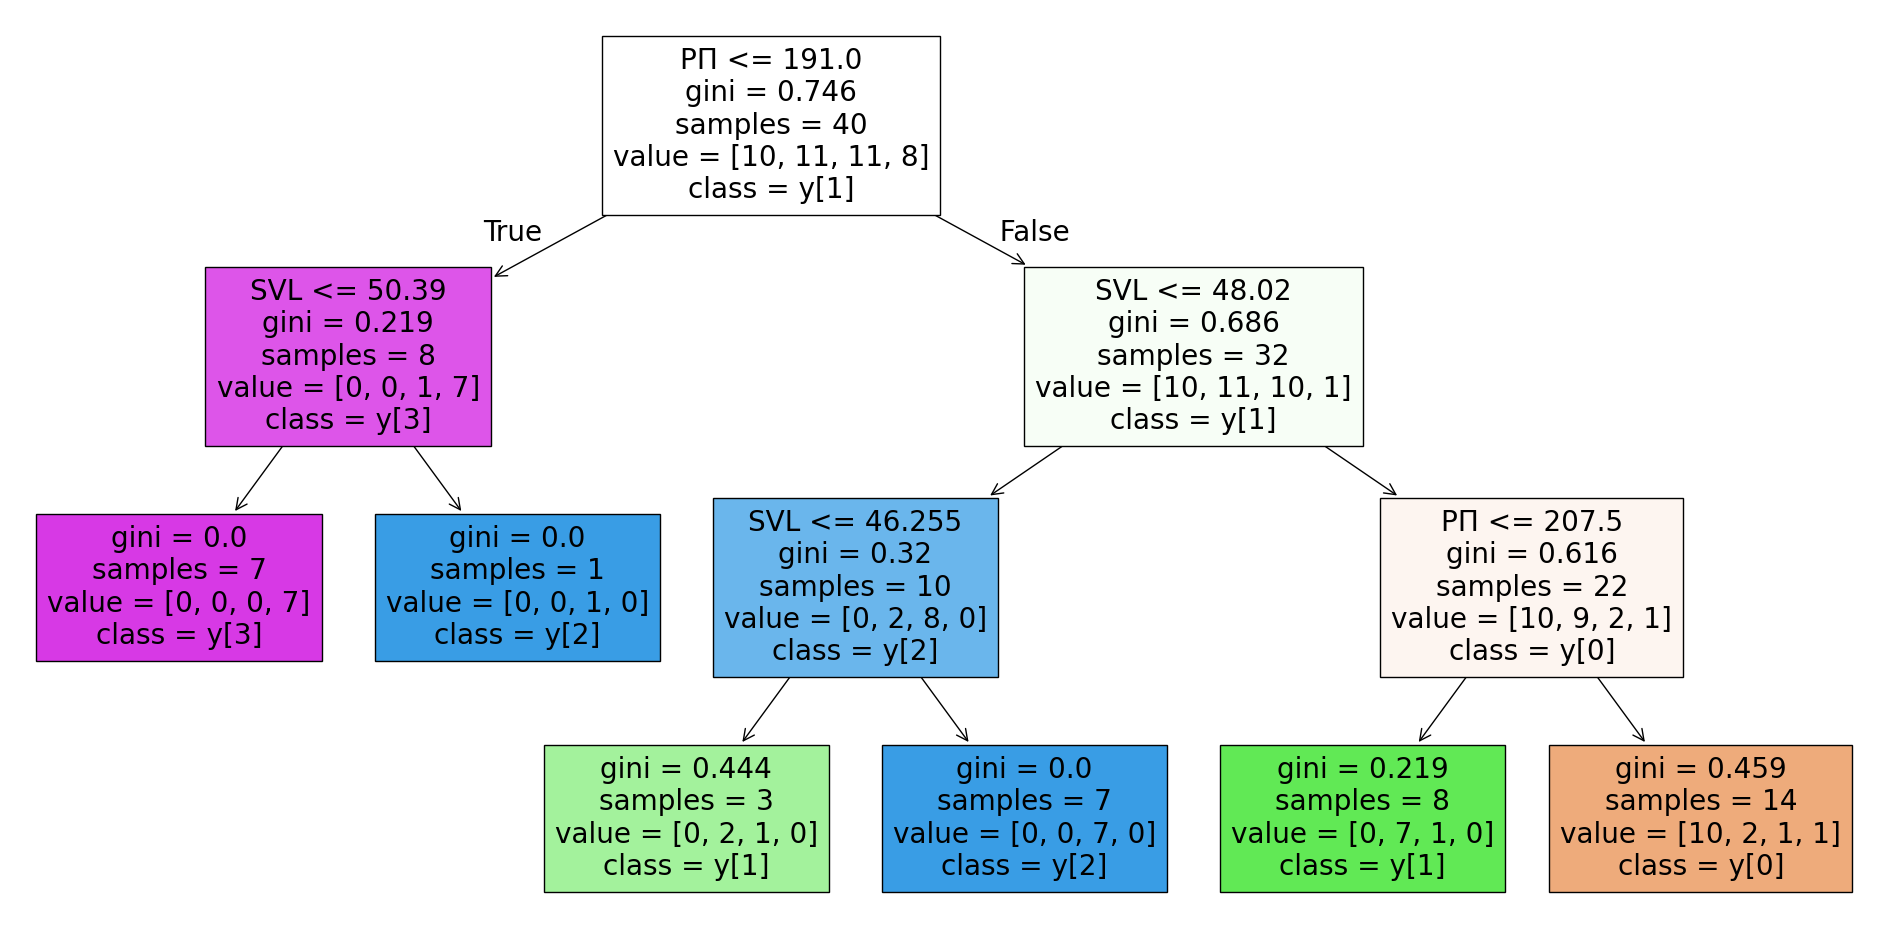

In [ ]:
plt.figure(figsize=(24, 12))
tree.plot_tree(clf, feature_names=list(significant_features_in_all), class_names=True, filled=True)
plt.show()

##Обучение без деления на тест и обучение


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
import matplotlib.pyplot as plt

# Входные данные
X = data_glaucoma_all[list(significant_features_in_all)]
y = data_glaucoma_all['стадия']

# Обучение дерева решений
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X.values, y.values)

DecisionTreeClassifier(max_depth=3, random_state=42)

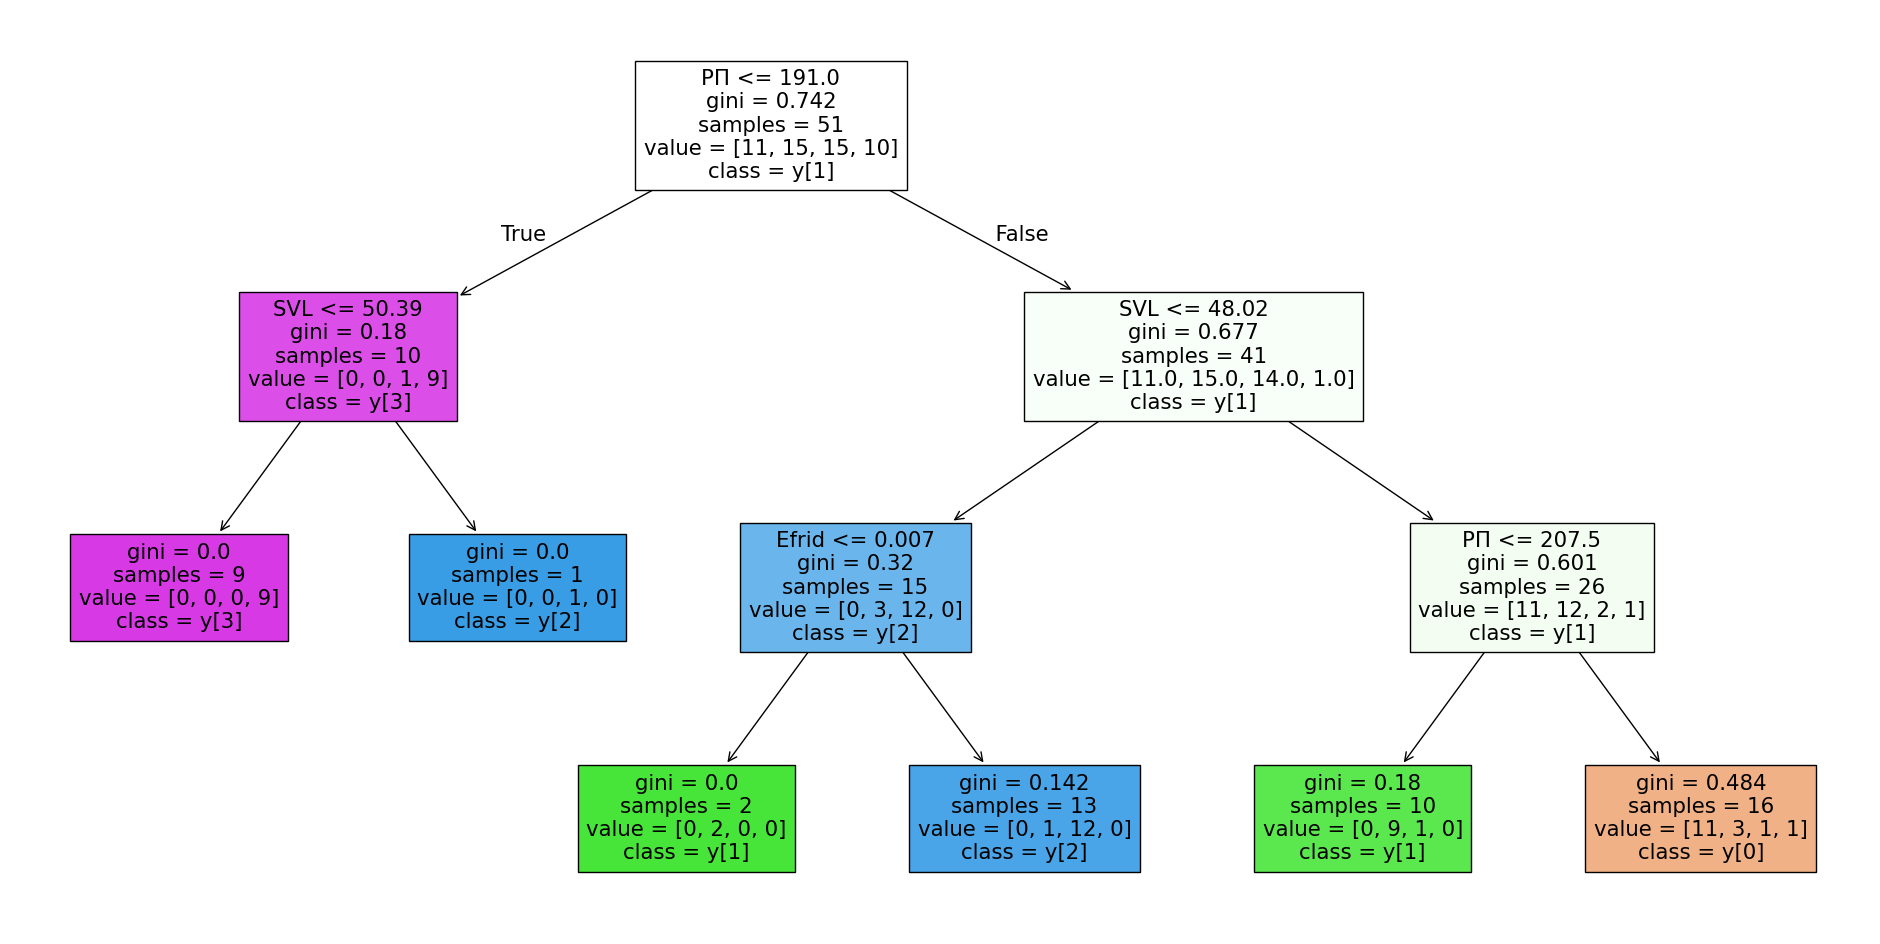

In [ ]:
plt.figure(figsize=(24, 12))
tree.plot_tree(clf, feature_names=list(significant_features_in_all), class_names=True, filled=True)
plt.show()

##Кросс-валидация при обучении

In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np

X = data_glaucoma_all[list(significant_features_in_all)]
y = data_glaucoma_all['стадия']

In [ ]:
loo = LeaveOneOut()
predictions = []
true_values = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    clf.fit(X_train.values, y_train.values)
    y_pred = clf.predict(X_test.values)

    predictions.append(y_pred[0])
    true_values.append(y_test.values[0])

In [ ]:
# Общая точность
accuracy = accuracy_score(true_values, predictions)
print(f"LOO точность модели: {accuracy:.2f}")

LOO точность модели: 0.71


Точность на нижней грани допустимого

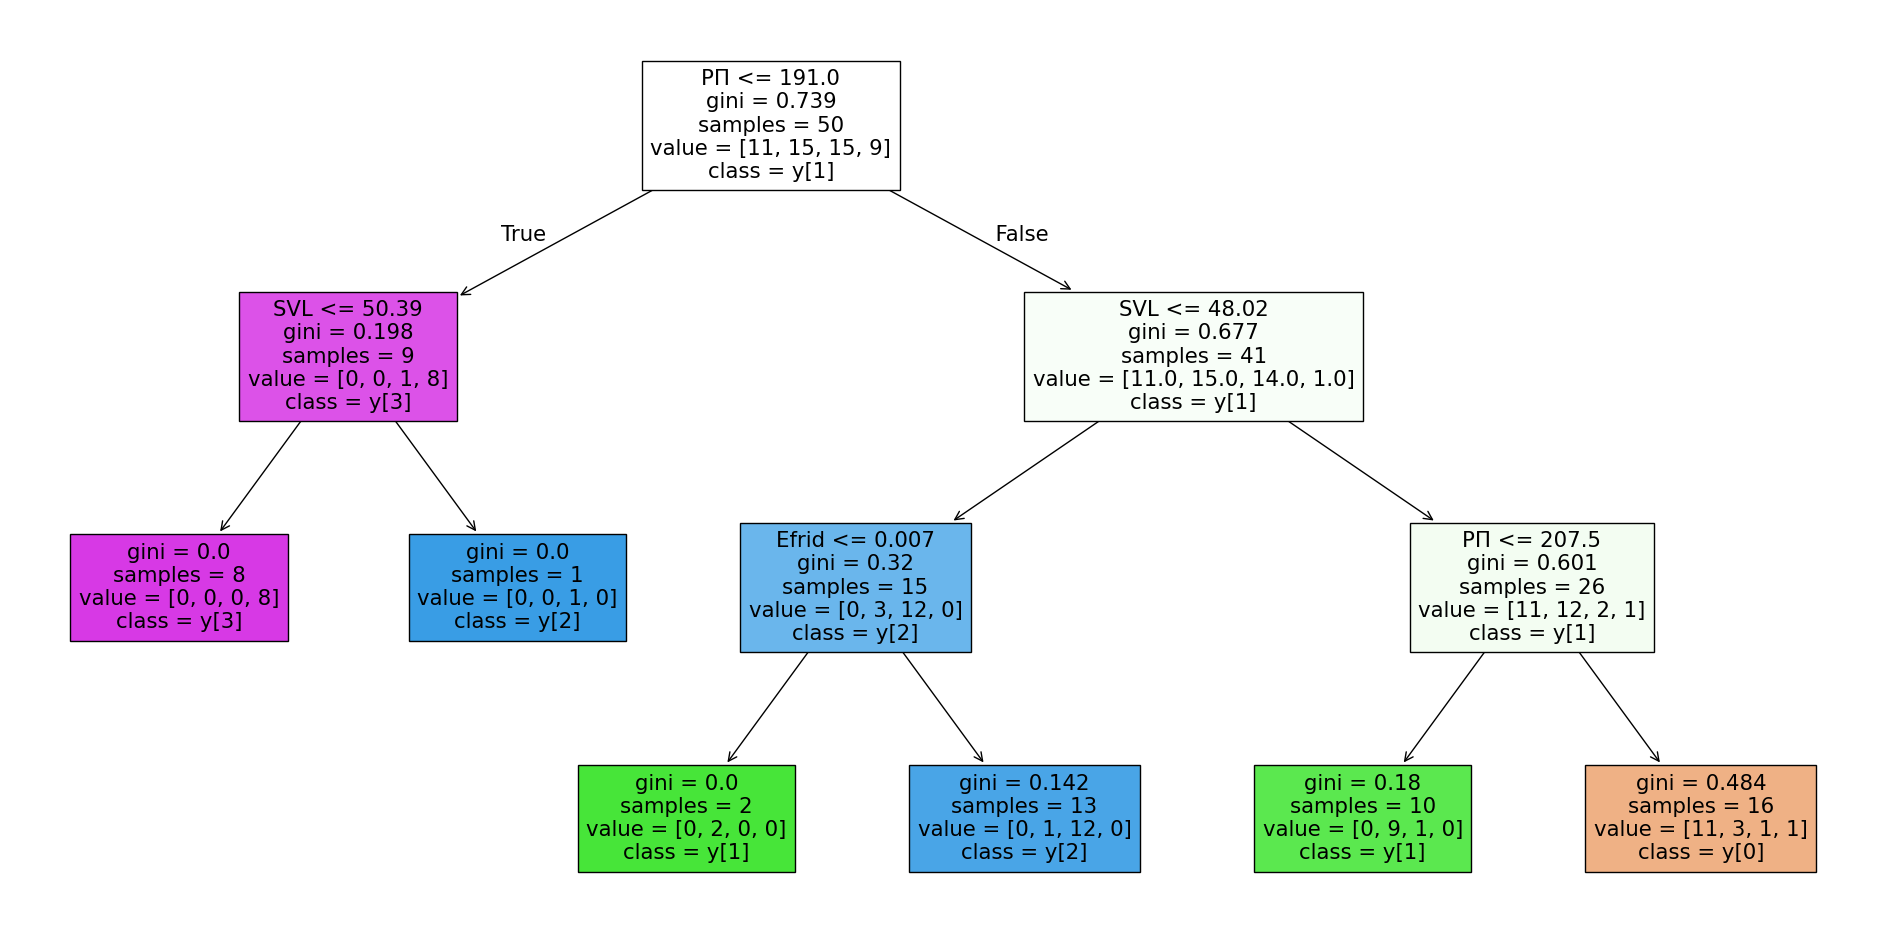

In [ ]:
plt.figure(figsize=(24, 12))
tree.plot_tree(clf, feature_names=list(significant_features_in_all), class_names=True, filled=True)
plt.show()

Данные здорового пациента (0 стадия)

In [ ]:
patient_input = {
    'ГлРП': 346.0,
    'РП': 245,
    'SVL': 56.3,
    'Efrid': 0.0162,
    'Коэфф ригидности склеральн капсулы глаза': 0.0162
}

In [ ]:
# Преобразуем в нужный формат
patient_vector = [patient_input[feat] for feat in significant_features_in_all]

In [ ]:
# Прогноз
predicted_stage = clf.predict([patient_vector])[0]
print(f"Предсказанная стадия глаукомы: {predicted_stage}")

Предсказанная стадия глаукомы: 0


##Метод медиан

In [ ]:
# 3. Метод медиан
# Считаем медианы по стадиям
stage_medians = {
    stage: data_glaucoma_all[data_glaucoma_all['стадия'] == stage][list(significant_features_in_all)].median().values
    for stage in sorted(data_glaucoma_all['стадия'].unique())
}

In [ ]:
# Функция предсказания
def predict_by_medians(sample, stage_medians):
    distances = {stage: np.linalg.norm(sample - med) for stage, med in stage_medians.items()}
    return min(distances, key=distances.get)

In [ ]:
# Предсказания по медианам
y_pred_medians = X.apply(lambda row: predict_by_medians(row.values, stage_medians), axis=1)

#Тестирование алгоритмов

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Входные данные
X = data_glaucoma_all[list(significant_features_in_all)]
y_true = data_glaucoma_all['стадия']

In [ ]:
# 2. Модель: Дерево решений
#2.1 Обучение на всей выборке
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X.values, y_true.values)
y_pred_tree = clf.predict(X.values)

In [ ]:
#Кросс-валидация
X = data_glaucoma_all[list(significant_features_in_all)]
y = data_glaucoma_all['стадия']

loo = LeaveOneOut()
preds_loo = []
true_loo = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    clf.fit(X_train.values, y_train.values)
    y_pred = clf.predict(X_test.values)

    preds_loo.append(y_pred[0])
    true_loo.append(y_test.values[0])

# Результаты
acc_loo = accuracy_score(true_loo, preds_loo)
#print(f"Точность дерева решений (Leave-One-Out): {acc_loo:.2f}")

# Таблица сравнения
#results_loo = pd.DataFrame({'Стадия в данных': true_loo,'Стадия (LOO дерево решений)': preds_loo})
#print(results_loo)

In [ ]:
# 3. Метод медиан
# Считаем медианы по стадиям
stage_medians = {
    stage: data_glaucoma_all[data_glaucoma_all['стадия'] == stage][list(significant_features_in_all)].median().values
    for stage in sorted(data_glaucoma_all['стадия'].unique())
}

In [ ]:
# Функция предсказания
def predict_by_medians(sample, stage_medians):
    distances = {stage: np.linalg.norm(sample - med) for stage, med in stage_medians.items()}
    return min(distances, key=distances.get)

In [ ]:
# Предсказания по медианам
y_pred_medians = X.apply(lambda row: predict_by_medians(row.values, stage_medians), axis=1)

In [ ]:
# 4. Создание таблицы сравнения
results_df = pd.DataFrame({
    'Стадия в данных': y_true.values,
    'Стадия (дерево решений, вся выборка)': y_pred_tree,
    'Стадия (дерево решений, CV)': preds_loo,
    'Стадия (медианы)': y_pred_medians
})

In [ ]:
# 5. Печать таблицы и точностей
results_df

,Стадия в данных,"Стадия (дерево решений, вся выборка)","Стадия (дерево решений, CV)",Стадия (медианы)
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,2,0
5,0,0,0,0
6,0,0,2,1
7,0,0,0,0
8,0,0,0,0
9,0,0,0,1


In [ ]:
print("Точность дерева решений:", accuracy_score(y_true, y_pred_tree))
print(f"Точность дерева решений (Leave-One-Out): {acc_loo:.8f}")
print("Точность правил по медианам:", accuracy_score(y_true, y_pred_medians))

Точность дерева решений: 0.8627450980392157
Точность дерева решений (Leave-One-Out): 0.70588235
Точность правил по медианам: 0.7058823529411765


Выведем строки, в которых результаты работы алгоритма не совпали с исходными данными

In [ ]:
mistakes_in_results = results_df.loc[((results_df['Стадия в данных'] != results_df['Стадия (дерево решений, вся выборка)']) | (results_df['Стадия в данных'] != results_df['Стадия (медианы)'])|(results_df['Стадия в данных'] != results_df['Стадия (дерево решений, CV)']))]
mistakes_in_results

,Стадия в данных,"Стадия (дерево решений, вся выборка)","Стадия (дерево решений, CV)",Стадия (медианы)
4,0,0,2,0
6,0,0,2,1
9,0,0,0,1
10,0,0,0,1
11,1,1,1,2
13,1,0,0,0
14,1,1,3,2
15,1,1,0,1
16,1,1,1,0
18,1,0,0,1


In [ ]:
print('Всего случаев несовпадения:', mistakes_in_results.shape[0])

Всего случаев несовпадения: 21


In [ ]:
#results_df.loc[(results_df['Стадия в данных'] != results_df['Стадия (дерево решений)'])]

In [ ]:
#results_df.loc[(results_df['Стадия в данных'] != results_df['Стадия (медианы)'])]